In [1]:
# build UMAP for Niches

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import rapids_singlecell as rsc
from pathlib import Path
import os

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix

In [5]:
# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'refined-manual-niches'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'
NEW_OBJ_V = 'refined-manual-niches-umap'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{NEW_OBJ_V}.h5ad'

# %% Load the unintegrated object
# use adata isntead of comb for the object only in this script
adata = sc.read_h5ad(CUR_OBJ_PATH)

In [6]:

# Same settings used when building niches
neighbors_k = 20
coords_key = "X_spatial_offset"
labels = "ann_lvl_3_refined"   # use exactly what you originally used

# Cell types
cell_types = adata.obs[labels].astype("category")
categories = cell_types.cat.categories.tolist()

# One-hot cell-type matrix
ct_mtx = (
    pd.get_dummies(cell_types)
    .reindex(columns=categories)
    .to_numpy(dtype=int)
)

# Spatial coordinates
coords = adata.obsm[coords_key]

# Spatial kNN
nn = NearestNeighbors(n_neighbors=neighbors_k + 1)
nn.fit(coords)

_, indices = nn.kneighbors(coords)

# Remove self
neighbor_indices = indices[:, 1:]

# Construct neighbour matrix
n_cells = adata.n_obs

row_idx = np.repeat(
    np.arange(n_cells),
    neighbors_k
)

col_idx = neighbor_indices.ravel()

nn_mtx = csr_matrix(
    (
        np.ones(len(row_idx)),
        (row_idx, col_idx),
    ),
    shape=(n_cells, n_cells),
)

# Cell-type composition of each spatial neighbourhood
niche_counts = nn_mtx @ ct_mtx

# Standardise exactly as in your original niche construction
scaler = StandardScaler()
niche_scaled = scaler.fit_transform(niche_counts)

# Save representation
adata.obsm["X_niche"] = niche_scaled

In [39]:
from sklearn.decomposition import PCA

# PCA on the SAME niche representation used for clustering
pca = PCA(
    n_components=15,
    random_state=SEED_VALUE
)

adata.obsm["X_niche_pca"] = pca.fit_transform(
    adata.obsm["X_niche"]
)

print(
    "Variance explained:",
    pca.explained_variance_ratio_.sum()
)

Variance explained: 0.7040095614554523


In [36]:
rsc.pp.neighbors(
    adata,
    use_rep="X_niche_pca",
    n_neighbors=15,
    key_added="niche_neighbors_pca",
    random_state=SEED_VALUE
)

rsc.tl.umap(
    adata,
    neighbors_key="niche_neighbors_pca",
    random_state=SEED_VALUE
)

# Give it a specific name so you don't overwrite/lose track
adata.obsm["X_umap_niche"] = adata.obsm["X_umap"].copy()

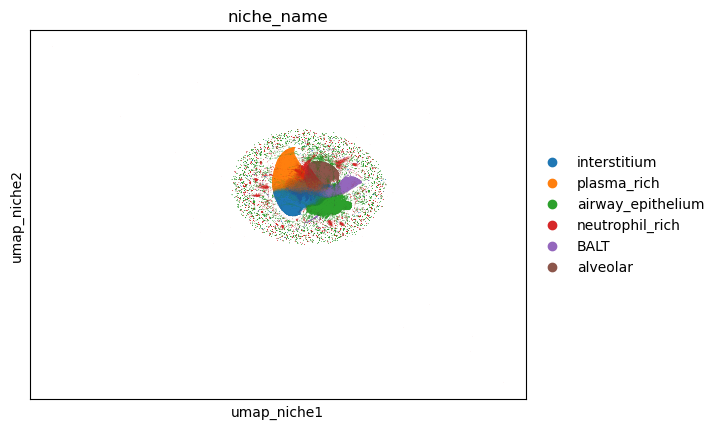

In [37]:
sc.pl.embedding(
    adata,
    basis="umap_niche",
    color="niche_name",
)

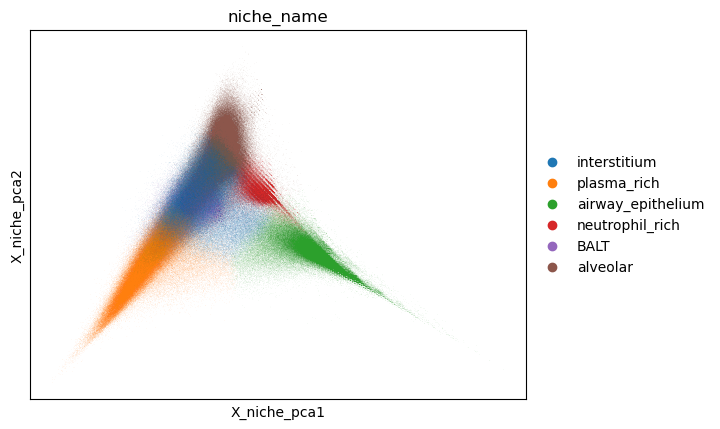

In [40]:
sc.pl.embedding(
    adata,
    basis="X_niche_pca",
    color="niche_name",
)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    adata.obsm["X_niche"],
    adata.obs["niche_name"]
)

print(score)